# 05 · 座標軸・刻度・標註

資料畫對了，接下來是「讓人一眼讀懂」。這課處理座標軸的細節：對數尺度、雙 y 軸、自訂刻度，以及用箭頭與文字標重點。

> 💡 可執行 notebook，`Shift+Enter` 跑每一格。

## 學習目標

- 用**對數尺度**呈現跨好幾個數量級的資料
- 用 `twinx()` 在同一張圖放**兩種不同單位**的資料
- 自訂 x 軸**刻度位置與標籤**
- 用 `annotate` 畫箭頭、加文字，把讀者的目光帶到重點

## 1. 對數尺度：當資料橫跨好幾個數量級

指數成長的資料用線性軸會「貼地 + 爆衝」，幾乎看不出早期變化。改成對數軸，指數成長會變成一條直線。

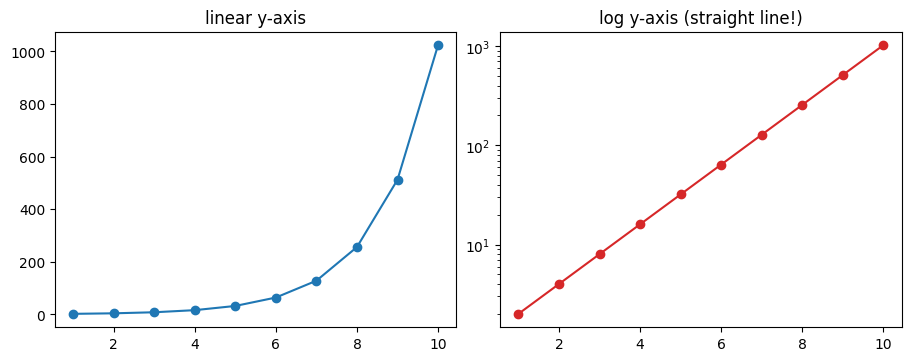

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1, 11)
y = 2.0 ** x            # 指數成長：2, 4, 8, ... 1024

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)

ax1.plot(x, y, marker="o", color="tab:blue")
ax1.set_title("linear y-axis")

ax2.plot(x, y, marker="o", color="tab:red")
ax2.set_yscale("log")    # 關鍵：y 軸改成對數尺度
ax2.set_title("log y-axis (straight line!)")
plt.show()

## 2. 雙 y 軸：twinx()

兩組資料單位不同（例如溫度 vs 降雨量），共用 x 軸但各自一條 y 軸。`twinx()` 會建立一個和原本共用 x 軸的新 Axes。

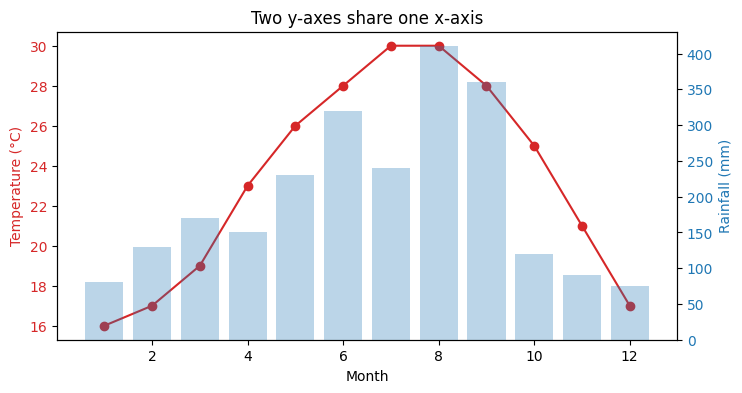

In [2]:
months = np.arange(1, 13)
temp = [16, 17, 19, 23, 26, 28, 30, 30, 28, 25, 21, 17]
rain = [80, 130, 170, 150, 230, 320, 240, 410, 360, 120, 90, 75]

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(months, temp, color="tab:red", marker="o", label="Temp")
ax1.set_xlabel("Month")
ax1.set_ylabel("Temperature (°C)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()        # 共用 x 軸的第二個 y 軸
ax2.bar(months, rain, alpha=0.3, color="tab:blue", label="Rain")
ax2.set_ylabel("Rainfall (mm)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax1.set_title("Two y-axes share one x-axis")
plt.show()

## 3. 自訂刻度

用 `set_xticks()` 指定刻度位置，第二個參數給對應的文字標籤。

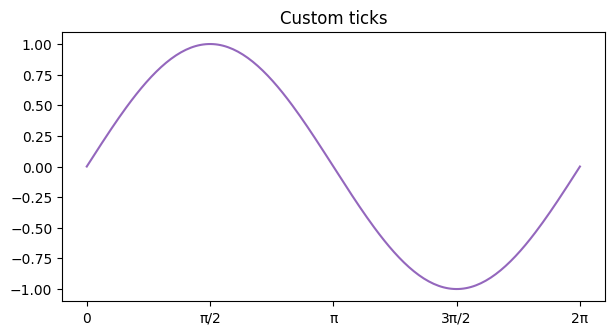

In [3]:
x = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(x, np.sin(x), color="tab:purple")

# 刻度放在 0, π/2, π, 3π/2, 2π，並用數學符號當標籤
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
ax.set_title("Custom ticks")
plt.show()

## 4. 標註：annotate

用箭頭 + 文字指出關鍵點，例如最高點。`xy` 是箭頭指的位置，`xytext` 是文字放的位置。

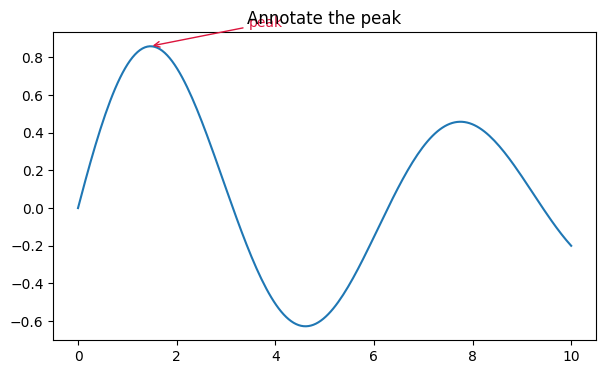

In [4]:
x = np.linspace(0, 10, 200)
y = np.sin(x) * np.exp(-x / 10)
peak = x[np.argmax(y)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, color="tab:blue")
ax.annotate(
    "peak",
    xy=(peak, y.max()),                 # 箭頭指向的點
    xytext=(peak + 2, y.max() + 0.1),   # 文字位置
    arrowprops=dict(arrowstyle="->", color="crimson"),
    color="crimson",
)
ax.set_title("Annotate the peak")
plt.show()

## 小結

- 跨數量級的資料用 `ax.set_yscale("log")`。
- 不同單位疊圖用 `ax.twinx()`，記得把各自 y 軸標籤上色以免混淆。
- `set_xticks()` + `set_xticklabels()` 完全掌控刻度。
- `ax.annotate()` 用箭頭把讀者目光帶到重點。

## 練習

1. 找一組「世界人口隨年份」的資料，分別用線性與對數 y 軸畫出來，比較哪個更能看出早期趨勢。
2. 在第 4 節的圖上，再標註出最低點。

下一課（最後一課）：樣式與美學——套用 style sheet、調 rcParams、用 colormap，以及**讓中文正常顯示**。